In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(
    "C:/Users/tayoa/OneDrive/Desktop/NJ_Title1_School_Analysis_confirmed/data/NJPubSchool.csv",
    skiprows=3,
    quoting=3,
    encoding="latin1",
    on_bad_lines="skip"   # skips malformed rows for now
)

# Clean up the Excel ="value" formatting
df = df.replace(r'="(.*)"', r'\1', regex=True)

In [3]:
print(df.shape)

(2505, 47)


In [4]:
#find amount of na rows
df.isnull().sum()

County Code                       0
County Name                       0
District Code                     0
District Name                     0
School Code                       0
School Name                       0
Princ. Title                     39
Princ. First Name                 1
Princ. Last Name                  1
Princ. Title 2                    1
Princ. Email                      1
Address1                          0
Address2                          0
City                              0
State                             0
Zip                               0
Mailing Address1                  0
Mailing Address2                  0
Mailing City                      0
Mailing State                     0
Mailing Zip                       0
HIB Title1                       75
HIB First Nname                   1
HIB Last Name                     1
HIB Title2                        1
Homeless Liaison Title1        2429
Homeless Liaison First Name    2425
Homeless Liaison Last Name  

In [5]:
#import csv dataset
df_title = pd.read_csv("C:/Users/tayoa/OneDrive/Desktop/NJ_Title1_School_Analysis_confirmed/data/newjerseypdf-40553.csv")
df_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 3 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   LEA ID                                      576 non-null    object
 1   District                                    575 non-null    object
 2   Title I Allocations Under the Recovery Act  575 non-null    object
dtypes: object(3)
memory usage: 13.6+ KB


In [6]:
#import excel file 
df_enrollment = pd.read_excel("C:/Users/tayoa/OneDrive/Desktop/NJ_Title1_School_Analysis_confirmed/data/enrollment_2425_1_.xlsx", sheet_name='School', skiprows=2)

In [7]:
df_enrollment.sample()

,County Code,County Name,District Code,District Name,School Code,School Name,Total Enrollment,White,%White,Black,...,Multilingual Learners,%Multilingual Learners,Migrant,%Migrant,Military,%Military,Homeless,%Homeless,Column1,Column2
927,13,Essex,3570.0,Newark Public School District,495.0,Louise A. Spencer Elementary School,774.0,10.0,1.3,251.0,...,277.0,35.8,0.0,0.0,0.0,0.0,3.0,0.4,3.0,0.4


In [8]:
# Check Title I dataframe
print(df_title.head())
print(df_title.dtypes)

   LEA ID              District Title I Allocations Under the Recovery Act
0  3400660         ABSECON CITY                                     90,622
1  3400690  ALEXANDRIA TOWNSHIP                                          0
2  3400720   ALLAMUCHY TOWNSHIP                                          0
3  3400750    ALLENDALE BOROUGH                                          0
4  3400780           ALLENHURST                                          0
LEA ID                                        object
District                                      object
Title I Allocations Under the Recovery Act    object
dtype: object


In [9]:
# Check Enrollment dataframe
print(df_enrollment.head())
print(df_enrollment.dtypes)

  County Code County Name  District Code                    District Name  \
0          01    Atlantic           10.0  Absecon Public Schools District   
1          01    Atlantic           10.0  Absecon Public Schools District   
2          01    Atlantic          110.0    Atlantic City School District   
3          01    Atlantic          110.0    Atlantic City School District   
4          01    Atlantic          110.0    Atlantic City School District   

   School Code                School Name  Total Enrollment  White  %White  \
0         50.0             Emma C Attales             392.0  171.0    43.6   
1         60.0             H Ashton Marsh             518.0  227.0    43.8   
2         10.0  Atlantic City High School            1731.0   90.0     5.2   
3        300.0     Brighton Avenue School             302.0    6.0     2.0   
4         50.0     Chelsea Heights School             267.0   10.0     3.7   

   Black  ...  Multilingual Learners  %Multilingual Learners  Migran

In [10]:
print(df_title.columns.tolist())

['LEA ID ', 'District', 'Title I Allocations Under the Recovery Act']


In [11]:
# Check the last 5 rows
print(df_title.tail())

                                               LEA ID   \
571                                            3418300   
572                                            3418330   
573                                            3418360   
574                                            3499999   
575  *    Actual amounts received by LEAs will be s...   

                     District Title I Allocations Under the Recovery Act  
571        WOOD-RIDGE BOROUGH                                          0  
572  WOODSTOWN-PILESGROVE REG                                     98,465  
573          WYCKOFF TOWNSHIP                                          0  
574          PART D SUBPART 2                                    888,360  
575                       NaN                                        NaN  


In [12]:
# Strip whitespace from all column names
df_title.columns = df_title.columns.str.strip()

# Drop any rows where LEA ID is not numeric (legend/footnote rows)
df_title = df_title[pd.to_numeric(df_title["LEA ID"], errors="coerce").notna()]

# Now reset the index
df_title = df_title.reset_index(drop=True)

print(df_title.tail())
print(df_title.shape)

      LEA ID                  District  \
570  3418270         WOODLYNNE BOROUGH   
571  3418300        WOOD-RIDGE BOROUGH   
572  3418330  WOODSTOWN-PILESGROVE REG   
573  3418360          WYCKOFF TOWNSHIP   
574  3499999          PART D SUBPART 2   

    Title I Allocations Under the Recovery Act  
570                                    172,986  
571                                          0  
572                                     98,465  
573                                          0  
574                                    888,360  
(575, 3)


In [13]:
# Drop the PART D SUBPART 2 row
df_title = df_title[df_title["District"] != "PART D SUBPART 2"].reset_index(drop=True)

# Strip whitespace from column names
df_title.columns = df_title.columns.str.strip()

# Extract district code from LEA ID (last 4 digits)
df_title["District Code"] = df_title["LEA ID"].astype(str).str[-4:].str.lstrip("0").astype(float)

# Clean allocation column
df_title["Title I Allocations Under the Recovery Act"] = (
    df_title["Title I Allocations Under the Recovery Act"]
    .str.replace(",", "")
    .astype(float)
)

# Merge
df_merged = pd.merge(
    df_enrollment,
    df_title[["District Code", "Title I Allocations Under the Recovery Act"]],
    on="District Code",
    how="left"
)

print(df_merged.shape)
df_merged.head()

(2528, 68)


,County Code,County Name,District Code,District Name,School Code,School Name,Total Enrollment,White,%White,Black,...,%Multilingual Learners,Migrant,%Migrant,Military,%Military,Homeless,%Homeless,Column1,Column2,Title I Allocations Under the Recovery Act
0,01,Atlantic,10.0,Absecon Public Schools District,50.0,Emma C Attales,392.0,171.0,43.6,53.0,...,11.0,0.0,0.0,0.0,0.0,12.0,3.1,12.0,3.1,NaN
1,01,Atlantic,10.0,Absecon Public Schools District,60.0,H Ashton Marsh,518.0,227.0,43.8,58.0,...,10.6,0.0,0.0,6.0,1.2,11.0,2.1,11.0,2.1,NaN
2,01,Atlantic,110.0,Atlantic City School District,10.0,Atlantic City High School,1731.0,90.0,5.2,554.0,...,14.1,0.0,0.0,11.0,0.6,35.0,2.0,35.0,2.0,0.0
3,01,Atlantic,110.0,Atlantic City School District,300.0,Brighton Avenue School,302.0,6.0,2.0,18.0,...,53.0,0.0,0.0,1.0,0.3,1.0,0.3,1.0,0.3,0.0
4,01,Atlantic,110.0,Atlantic City School District,50.0,Chelsea Heights School,267.0,10.0,3.7,55.0,...,21.7,0.0,0.0,1.0,0.4,4.0,1.5,4.0,1.5,0.0


In [14]:
# Filter for Title I schools only (allocation > 0)
df_title1_only = df_merged[df_merged["Title I Allocations Under the Recovery Act"] > 0]

# Add up grades 5-8 columns
df_title1_only = df_title1_only.copy()
df_title1_only["Grades 5-8 Total"] = (
    df_title1_only["Fifth Grade"] +
    df_title1_only["Sixth Grade"] +
    df_title1_only["Seventh Grade"] +
    df_title1_only["Eighth Grade"]
)

# Group by county
q1 = (df_title1_only.groupby("County Name")["Grades 5-8 Total"]
      .sum()
      .reset_index()
      .sort_values("Grades 5-8 Total", ascending=False))

print(q1)


   County Name  Grades 5-8 Total
12   Middlesex           24018.0
1       Bergen           12913.0
9       Hudson           12772.0
16     Passaic            9332.0
13    Monmouth            7971.0
20       Union            6595.0
3       Camden            5884.0
15       Ocean            5549.0
2   Burlington            4991.0
6   Cumberland            4938.0
11      Mercer            4749.0
14      Morris            4569.0
18    Somerset            4553.0
8   Gloucester            3639.0
7        Essex            2477.0
5     Charters            2224.0
4     Cape May            1857.0
10   Hunterdon            1773.0
0     Atlantic            1589.0
19      Sussex             915.0
21      Warren             747.0
17       Salem             358.0


In [15]:
#group by District name and school name to find counties by grade 5-8 enrollement
q2 = (df_title1_only.groupby(["District Name", "School Name"])["Grades 5-8 Total"]
      .sum()
      .reset_index()
      .sort_values(["District Name", "Grades 5-8 Total"], ascending=[True, False]))

print(q2)

                           District Name                          School Name  \
0    Alexandria Township School District           Alexandria Township School   
1      Atlantic Community Charter School    Atlantic Community Charter School   
3      Berkeley Township School District  Berkeley Township Elementary School   
2      Berkeley Township School District           Bayville Elementary School   
4      Berkeley Township School District     Clara B. Worth Elementary School   
..                                   ...                                  ...   
749       Woodcliff Lake School District         Dorchester Elementary School   
753        Woodland Park School District               Memorial Middle School   
751        Woodland Park School District              Beatrice Gilmore School   
752        Woodland Park School District                 Charles Olbon School   
754        Woodland Park School District                           School One   

     Grades 5-8 Total  
0  

In [16]:
#Top 10 schools by grade 5-8 enrollment
q2_filtered = q2[q2["Grades 5-8 Total"] > 0].sort_values(
    ["District Name", "Grades 5-8 Total"], ascending=[True, False]
)
print(q2_filtered.shape)
print(q2_filtered)

(501, 3)
                               District Name  \
0        Alexandria Township School District   
1          Atlantic Community Charter School   
3          Berkeley Township School District   
11         Bernards Township School District   
6          Bernards Township School District   
..                                       ...   
748  Woodbury Heights Public School District   
750           Woodcliff Lake School District   
749           Woodcliff Lake School District   
753            Woodland Park School District   
751            Woodland Park School District   

                             School Name  Grades 5-8 Total  
0             Alexandria Township School             168.0  
1      Atlantic Community Charter School             153.0  
3    Berkeley Township Elementary School             594.0  
11           William Annin Middle School            1122.0  
6                      Cedar Hill School             103.0  
..                                   ...        

In [17]:
print(q1)

   County Name  Grades 5-8 Total
12   Middlesex           24018.0
1       Bergen           12913.0
9       Hudson           12772.0
16     Passaic            9332.0
13    Monmouth            7971.0
20       Union            6595.0
3       Camden            5884.0
15       Ocean            5549.0
2   Burlington            4991.0
6   Cumberland            4938.0
11      Mercer            4749.0
14      Morris            4569.0
18    Somerset            4553.0
8   Gloucester            3639.0
7        Essex            2477.0
5     Charters            2224.0
4     Cape May            1857.0
10   Hunterdon            1773.0
0     Atlantic            1589.0
19      Sussex             915.0
21      Warren             747.0
17       Salem             358.0


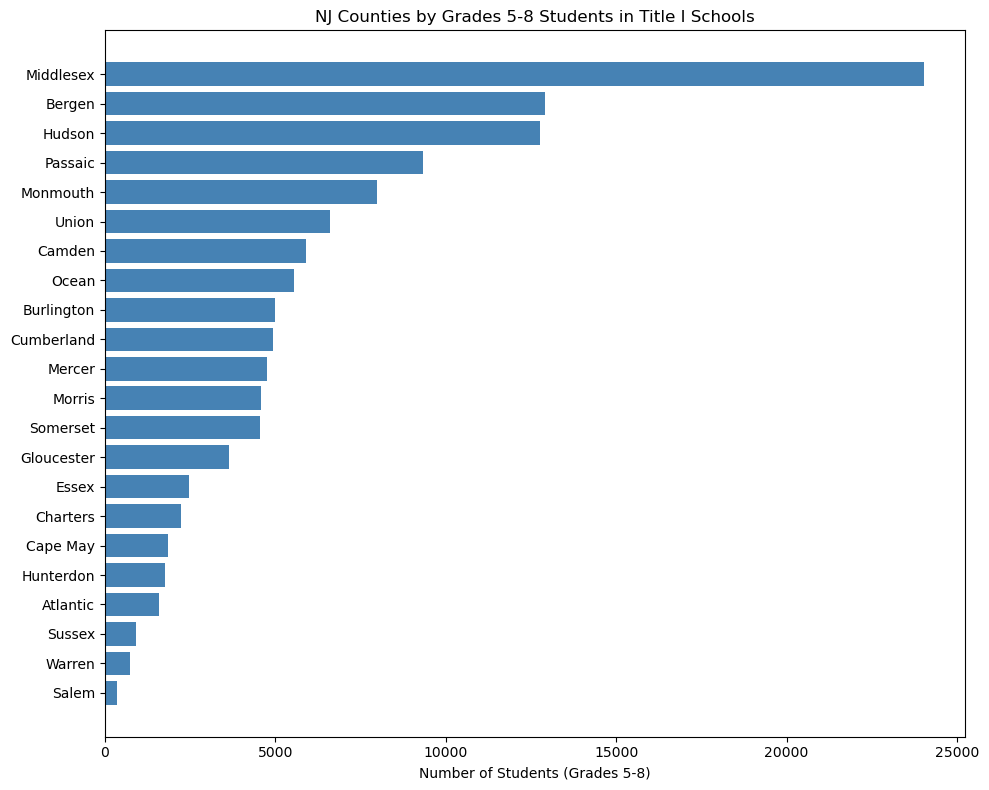

In [18]:
import matplotlib.pyplot as plt

q1_sorted = q1.sort_values("Grades 5-8 Total", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(q1_sorted["County Name"], q1_sorted["Grades 5-8 Total"], color="steelblue")
plt.xlabel("Number of Students (Grades 5-8)")
plt.title("NJ Counties by Grades 5-8 Students in Title I Schools")
plt.tight_layout()
plt.show()

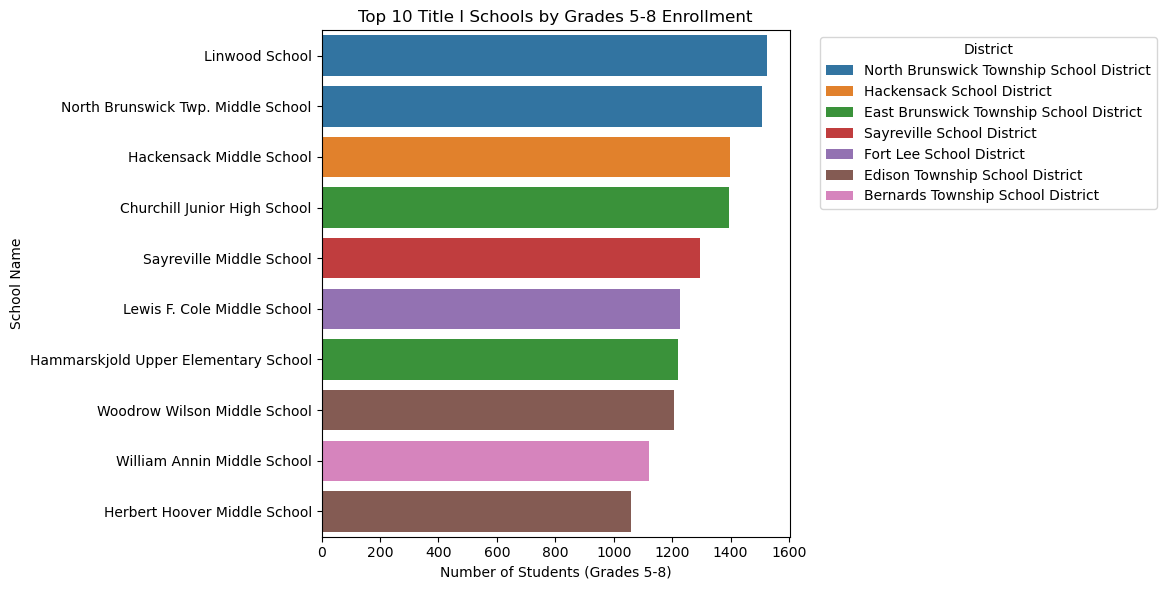

In [19]:
import seaborn as sns

top10 = (q2_filtered.sort_values("Grades 5-8 Total", ascending=False)
         .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10,
    x="Grades 5-8 Total",
    y="School Name",
    hue="District Name",
    dodge=False,
    palette="tab10"
)
plt.xlabel("Number of Students (Grades 5-8)")
plt.ylabel("School Name")
plt.title("Top 10 Title I Schools by Grades 5-8 Enrollment")
plt.legend(title="District", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

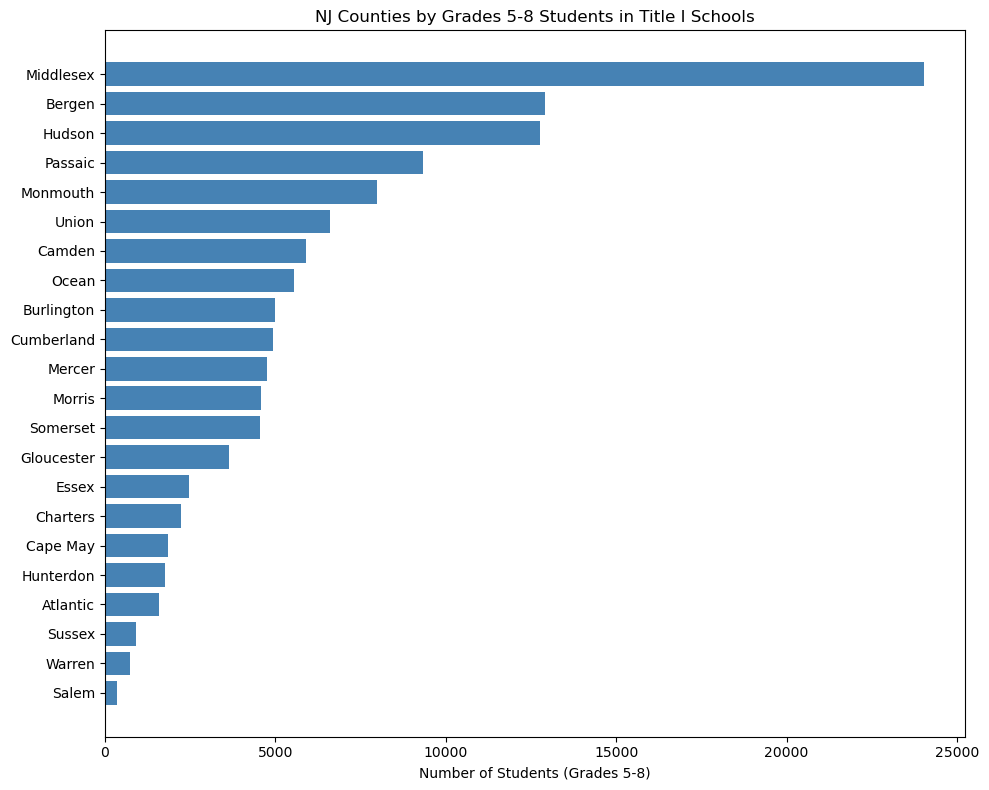

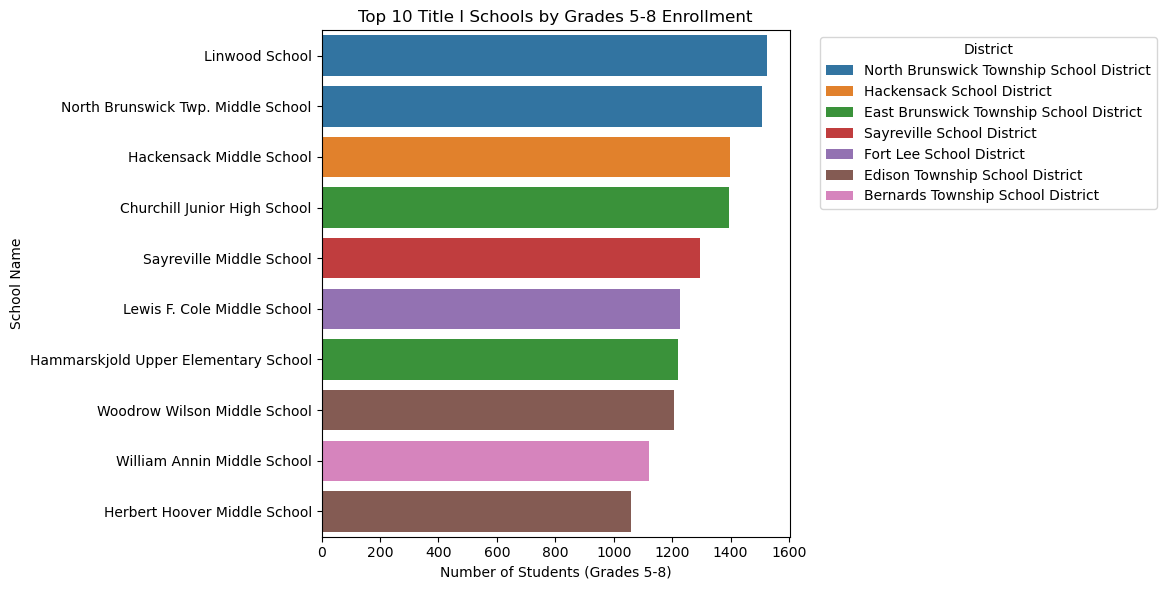

In [20]:
# Q1 - Counties chart
plt.figure(figsize=(10, 8))
plt.barh(q1_sorted["County Name"], q1_sorted["Grades 5-8 Total"], color="steelblue")
plt.xlabel("Number of Students (Grades 5-8)")
plt.title("NJ Counties by Grades 5-8 Students in Title I Schools")
plt.tight_layout()
plt.savefig("C:/Users/tayoa/OneDrive/Desktop/NJ_Title1_School_Analysis_confirmed/dashboard/q1_counties_chart.png", dpi=150)
plt.show()

# Q2 - Top 10 schools chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="Grades 5-8 Total", y="School Name", hue="District Name", dodge=False, palette="tab10")
plt.xlabel("Number of Students (Grades 5-8)")
plt.ylabel("School Name")
plt.title("Top 10 Title I Schools by Grades 5-8 Enrollment")
plt.legend(title="District", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("C:/Users/tayoa/OneDrive/Desktop/NJ_Title1_School_Analysis_confirmed/dashboard/q2_top10_schools_chart.png", dpi=150)
plt.show()